In [ ]:
# 경고문 제거
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install -U transformers

# GPU를 활용한 T5 모델 추론(요약문 생성)

활용할 모델: t5-base-korean-text-summary

1.   pko-t5-base를 요약문 생성 데이터로 fine-tuning한 모델
2.   pko-t5는 한국어 전용 데이터로 학습한 t5 모델



https://huggingface.co/lcw99/t5-base-korean-text-summary


### **gpu 환경 세팅 방법**

1) Colab의 파일명 아래 '런타임' 탭 클릭

2) '런타임 유형 변경' 클릭

3) '하드웨어 가속기'가 현재 T4 GPU(default) 혹은 A100 GPU, L4 GPU으로 되어 있는지 확인

4) 만약 '하드웨어 가속기'가 GPU로 설정이 안되어 있다면, T4 GPU를 클릭하고 설정

	- '런타임 연결 해제 및 삭제' 메시지가 뜰탠데, 확인 클릭


## 1. 데이터 다운로드

https://www.bigkinds.or.kr/

0) 우측 상단 '사람 아이콘'을 통해 로그인 탭으로 이동해 로그인을 진행한다.

1) 원하는 키워드를 검색창에 입력하고 상세검색을 클릭한다.

2) 원하는 조건(기간, 언론사 등)을 설정하고 '적용하기'를 클릭한다.

3) STEP 03. 분석 결과 및 시각화 탭을 클릭한다.

4) STEP 03 최하단의 '엑셀 다운로드' 버튼을 클릭한다.



`샘플 파일`

: 지난 1개월(6.20~7.20) 간 'LLM'(Large Language Model)을 포함한 기사

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/main/NewsResult_20250620-20250720.xlsx

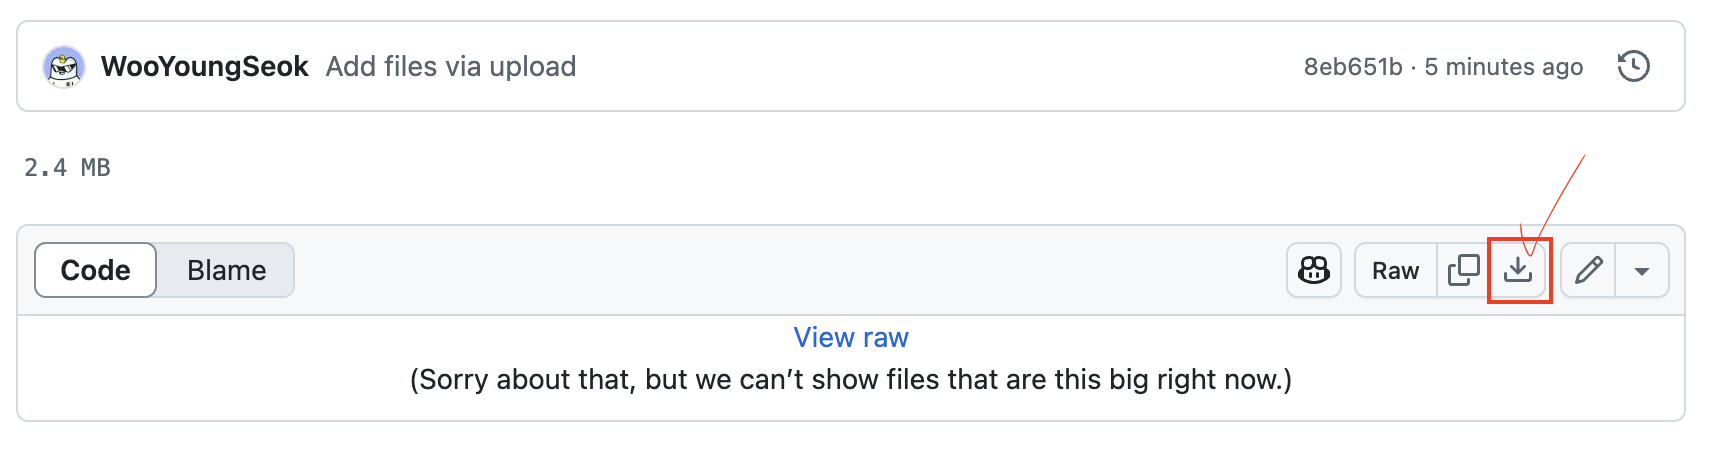

**다운로드 버튼 클릭!**


In [4]:
import pandas as pd

news = pd.read_excel("/content/NewsResult_20250620-20250720.xlsx")

print("뉴스 기사 수: ",len(news))
news.head()

뉴스 기사 수:  1917


,뉴스 식별자,일자,언론사,기고자,제목,통합 분류1,통합 분류2,통합 분류3,사건/사고 분류1,사건/사고 분류2,사건/사고 분류3,인물,위치,기관,키워드,특성추출(가중치순 상위 50개),본문,URL,분석제외 여부
0,2.100401e+06,20250720,메트로경제,이혜민,"""클로드 큐원 넘었다?"" LG '엑사원 4.0', '진짜 실력' 따져보니",IT_과학>IT_과학일반,NaN,NaN,NaN,NaN,NaN,고메스,"아시아,미국,중국","알리바바,미국,엑사,코히어,중국,FT,테크크런치,제시 도지 앨런,자원,파이낸셜타임스...","클로드,큐원,4.0,LG,엑사원,4.0,진짜,실력,챗GPT,생성,연구원,LG,AI,...","ai,lg,벤치마크,전문가,엑사원,하이브리드,해결력,관계자,테크크런치,큐원,미국,필...",챗GPT로 생성한 'LG AI 연구원이 개발한 '엑사원 4.0' 모델이 타 경쟁사들...,http://www.metroseoul.co.kr/article/2025072050...,NaN
1,4.100078e+06,20250720,뉴스핌,양태훈,"LG유플러스, 금융 특화 AI로 글로벌 시장 진출",IT_과학>모바일,경제>자동차,IT_과학>보안,NaN,NaN,NaN,전병기,"아마존,아마존 베드록","마켓플레이스,AX,LG유플러스,베드록,LG","LG유플러스,AI,금융,특화,진출,글로벌,시장,양태훈,LG유플러스,글로벌,클라우드,...","ai,익시젠,유플러스,lg유플러스,베드록,아마존,lg,100여,전병기,aws,sll...",[서울=뉴스핌] 양태훈 기자 = LG유플러스는 20일 글로벌 클라우드 서비스 기업 ...,https://www.newspim.com/news/view/20250720000142,NaN
2,1.100801e+06,20250720,조선일보,김강한 기자,일론 머스크도 견제하는 한국 AI 스타트업...업스테이지 10대 프런티어 AI 개발...,스포츠>스포츠일반,IT_과학>IT_과학일반,NaN,NaN,NaN,NaN,"김성훈,일론 머스크","미국,중국,한국","구글,프랑스,xAI,유일,딥시크,업스테이지,트위터,스타트업","일론,머스크,견제,스타트업,한국,AI,업스테이지,선정,프런티어,AI,개발사,AI,인...","업스테이지,ai,프런티어,1위,개발사,스타트업,그록,딥시크,아티피셜,xai,한국,김...",국내 AI(인공지능) 스타트업 ‘업스테이지’가 한국에서 유일하게 10대 프런티어 모...,https://www.chosun.com/economy/tech_it/2025/07...,NaN
3,1.100101e+06,20250720,경향신문,노도현 기자 hyunee@kyunghyang.com,"오픈AI 추론 AI 모델, 국제수학올림피아드 금메달 땄다?",스포츠>스포츠일반,IT_과학>모바일,NaN,NaN,NaN,NaN,"마커스,샘 올트먼","최고경영자,알렉산더","구글,자원,IMO","오픈,AI,추론,AI,모델,국제,수학,올림피아드,금메달,오픈AI,개발사,오픈,AI,...","imo,ai,오픈ai,금메달,개발사,올트먼,국제수학올림피아드,게리,평가자,비평가,경영자",챗GPT 개발사 오픈AI는 자사의 미공개 추론 인공지능(AI) 모델이 세계적 권위의...,https://www.khan.co.kr/article/202507201510001,NaN
4,2.100501e+06,20250720,파이낸셜뉴스,박성현 기자 (psh@fnnews.com),"""독도는 한국 땅"" KT의 LLM '믿음 2.0' 써보니",미분류,NaN,NaN,NaN,NaN,NaN,"소버린,이성엽","독도,한일,한국,대한민국,우면,서초구","고려대,통계청,세울,KT,독도,기술경영전문대학원","독도,한국,KT,2.0,LLM,믿음,2.0,독도,역사적,근거,실효,지배,근거,제기,...","한국,독도,kt,보고서,ai,소버린,llm,내년도,통계청,챗gpt,고려대,이성엽,p...","""독도는 누구땅?"" 물으니 역사적근거, 실효적 지배 등 근거 제기 \n상사에게 보낼...",http://www.fnnews.com/news/202507171133032905,NaN


In [5]:
# "일자", "언론사", "제목", "본문" 열로만 구성
news = news[["일자", "언론사", "제목", "본문"]]
news.head()

,일자,언론사,제목,본문
0,20250720,메트로경제,"""클로드 큐원 넘었다?"" LG '엑사원 4.0', '진짜 실력' 따져보니",챗GPT로 생성한 'LG AI 연구원이 개발한 '엑사원 4.0' 모델이 타 경쟁사들...
1,20250720,뉴스핌,"LG유플러스, 금융 특화 AI로 글로벌 시장 진출",[서울=뉴스핌] 양태훈 기자 = LG유플러스는 20일 글로벌 클라우드 서비스 기업 ...
2,20250720,조선일보,일론 머스크도 견제하는 한국 AI 스타트업...업스테이지 10대 프런티어 AI 개발...,국내 AI(인공지능) 스타트업 ‘업스테이지’가 한국에서 유일하게 10대 프런티어 모...
3,20250720,경향신문,"오픈AI 추론 AI 모델, 국제수학올림피아드 금메달 땄다?",챗GPT 개발사 오픈AI는 자사의 미공개 추론 인공지능(AI) 모델이 세계적 권위의...
4,20250720,파이낸셜뉴스,"""독도는 한국 땅"" KT의 LLM '믿음 2.0' 써보니","""독도는 누구땅?"" 물으니 역사적근거, 실효적 지배 등 근거 제기 \n상사에게 보낼..."


In [6]:
# "본문" 열 데이터가 없으면 제거

news.dropna(subset=['본문'], inplace=True)
news

,일자,언론사,제목,본문
0,20250720,메트로경제,"""클로드 큐원 넘었다?"" LG '엑사원 4.0', '진짜 실력' 따져보니",챗GPT로 생성한 'LG AI 연구원이 개발한 '엑사원 4.0' 모델이 타 경쟁사들...
1,20250720,뉴스핌,"LG유플러스, 금융 특화 AI로 글로벌 시장 진출",[서울=뉴스핌] 양태훈 기자 = LG유플러스는 20일 글로벌 클라우드 서비스 기업 ...
2,20250720,조선일보,일론 머스크도 견제하는 한국 AI 스타트업...업스테이지 10대 프런티어 AI 개발...,국내 AI(인공지능) 스타트업 ‘업스테이지’가 한국에서 유일하게 10대 프런티어 모...
3,20250720,경향신문,"오픈AI 추론 AI 모델, 국제수학올림피아드 금메달 땄다?",챗GPT 개발사 오픈AI는 자사의 미공개 추론 인공지능(AI) 모델이 세계적 권위의...
4,20250720,파이낸셜뉴스,"""독도는 한국 땅"" KT의 LLM '믿음 2.0' 써보니","""독도는 누구땅?"" 물으니 역사적근거, 실효적 지배 등 근거 제기 \n상사에게 보낼..."
...,...,...,...,...
1912,20250620,한국일보,결국은 인프라 경쟁 '예견된 난관' 데이터 GPU 부족 문제부터 풀어야,한국전자통신연구원(ETRI)은 지난해 한국어 중심 소형언어모델(SLM)인 ‘이글’을...
1913,20250620,서울신문,하정우 “AI가 국가 존망 좌우 제 역량 활용할 기회”,국무회의 의결 이공계 지원법 설명 \n과학기술 인재 전 생애주기 지원 \n“수석 고...
1914,20250620,경기일보,"“AI행정시대 막 연다” 경기도, AI기업 상생 협력 선언 공공서비스 개발 추진",경기도가 19일 경기도청에서 ‘경기도-AI기업 상생협력 공동선언식’과 ‘경기 생성형...
1915,20250620,브릿지경제,"LG유플러스-부산대, AI 기반 교육지원시스템 구축 협력",LG유플러스는 부산대학교와 AI 기반 맞춤형 교육지원 시스템 구축을 위한 업무협약을...


### 🧪 Toy 데이터셋 만들기(뉴스 기사 샘플링)


*   1917개 기사를 요약하는데, 약 50분이 소요되기 때문
*   Toy 데이터셋을 통해서 텍스트 요약 실습을 빠르게 진행

💡 전체 본문에 대해 처리하고 싶으면,

아래 나올 텍스트 요약문 생성 코드에서 전체 본문 데이터로 변수 수정

(#####################################################

#####################################################

으로 둘러싸인 부분 확인)


In [7]:
# 텍스트 전처리 후, 데이터 프레임에서 10개의 뉴스 기사만 샘플링하여 toy 데이터셋 구성
news_toy = news.sample(n=10, random_state=42) # 10개의 기사를 랜덤으로 샘플링 (재현성을 위해 random_state 고정)
print("Toy 데이터셋 뉴스 기사 수: ", len(news_toy)) # 샘플링된 toy 데이터셋의 크기 출력
news_toy.head() # toy 데이터셋의 상위 5개 행 출력하여 확인

Toy 데이터셋 뉴스 기사 수:  10


,일자,언론사,제목,본문
950,20250703,파이낸셜뉴스,"KT, B2B 특화 ‘한국형 AI모델’ 독자 개발 AI 전환 가속 [소버린AI 경쟁...","업계, 통신 기반 수익구조 탈피 \nKT, 한국어 최적화 ‘믿음 2.0’ \nSKT..."
1468,20250625,메트로경제,"SKT, 에이닷 통화요약에 리벨리온 AI 반도체 적용",리벨리온의 신경망처리장치(NPU)를 적용한 서버기판. /SKT SK텔레콤은 '에이닷...
609,20250710,이데일리,"중기부, AX 스타트업 90곳 집중 육성한다",[이데일리 김응태 기자] 중소벤처기업부는 ‘인공지능 대전환’(AX) 기술 기반 스타...
495,20250713,디지털타임스,"[오늘의 DT인] “6G, 속도 아닌 AI 네트워크 인프라가 핵심 韓 실증 주도 골...",“6G의 경쟁력은 속도가 아닌 인공지능(AI) 서비스를 뒷받침할 서비스 품질(QoS...
1323,20250627,이투데이,"애드포러스, LLM 기반 자체 생성형 AI 플랫폼 고도화 시장 점유율 극대화",[이투데이] 박정호 기자 (godot@etoday.co.kr)\n\n\n\n신영스팩...


## 2. 실습 환경 준비(라이브러리, 모델 로드)

* 30초 정도 소요

In [8]:
# Hugging Face Transformers에서 사전학습된 T5 모델과 토크나이저 로드
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 문장 분리 등을 위한 NLTK 패키지 사용
import nltk
nltk.download('punkt')        # 문장 토큰화를 위한 기본 리소스 다운로드
nltk.download('punkt_tab')    # 일부 환경에서는 punkt_tab도 필요함 (Colab 오류 방지용)

# 진행 상황을 시각적으로 보여주는 라이브러리 (주피터 노트북용)
from tqdm.notebook import tqdm

# ✅ GPU 사용 여부 확인 및 설정
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 현재 디바이스: {device}")

# 요약용으로 사용할 사전학습된 한국어 T5 모델 불러오기
model_dir = "lcw99/t5-base-korean-text-summary"
tokenizer = AutoTokenizer.from_pretrained(model_dir)  # 토크나이저 로드
model = AutoModelForSeq2SeqLM.from_pretrained(model_dir).to(device)  # 모델 로드

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ 현재 디바이스: cuda


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

## 🔁 3. 요약 생성 및 저장
* Toy 데이터셋 기준 약 15초 소요

In [9]:
# 요약 결과 저장할 리스트
summaries = []

# 진행상황 표시를 위한 tqdm 사용
######################################################
for text in tqdm(news_toy['본문']): # 전체 데이터를 요약하기 위해서는 news['본문']으로 수정
######################################################
    try:
        # 1. 프롬프트 추가
        input_text = ["summarize: " + text]

        # 2. 토큰화
        tokenized = tokenizer(
            input_text,
            max_length=5096, # 입력 텍스트 길이에 따라 넉넉히 조정
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)

        # 3. 모델 요약 생성
        output = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            do_sample=True,
            min_length=10,
            max_length=256
        )

        # 4. 디코딩
        decoded_output = tokenizer.batch_decode(output, skip_special_tokens=True)[0]

        # 5. 문장 분할 후 첫 문장 추출
        summary = nltk.sent_tokenize(decoded_output.strip())[0]

    except Exception as e:
        summary = "[요약 실패] " + str(e)

    summaries.append(summary)

# 6. DataFrame에 새로운 열로 추가
######################################################
news_toy['요약'] = summaries  # 전체 데이터를 요약하기 위해서는 news['요약']으로 수정
######################################################

  0%|          | 0/10 [00:00<?, ?it/s]

## 🔍 4. 요약문 확인하기

In [10]:
news_toy.head()

,일자,언론사,제목,본문,요약
950,20250703,파이낸셜뉴스,"KT, B2B 특화 ‘한국형 AI모델’ 독자 개발 AI 전환 가속 [소버린AI 경쟁...","업계, 통신 기반 수익구조 탈피 \nKT, 한국어 최적화 ‘믿음 2.0’ \nSKT...",통신사들이 LLM을 공개한 배경에는 이통 3사의 가입자 수가 약 5000만 명에 불...
1468,20250625,메트로경제,"SKT, 에이닷 통화요약에 리벨리온 AI 반도체 적용",리벨리온의 신경망처리장치(NPU)를 적용한 서버기판. /SKT SK텔레콤은 '에이닷...,SK텔레콤은 주요 인공지능 서비스에 리벨리온의 신경망처리장치를 적용한다고 밝혔으며 ...
609,20250710,이데일리,"중기부, AX 스타트업 90곳 집중 육성한다",[이데일리 김응태 기자] 중소벤처기업부는 ‘인공지능 대전환’(AX) 기술 기반 스타...,중소벤처기업부는 AX 기술 기반 스타트업의 성장을 돕는 핵심 도메인 AX 스타트업 ...
495,20250713,디지털타임스,"[오늘의 DT인] “6G, 속도 아닌 AI 네트워크 인프라가 핵심 韓 실증 주도 골...",“6G의 경쟁력은 속도가 아닌 인공지능(AI) 서비스를 뒷받침할 서비스 품질(QoS...,최 6G사업단장은 정보통신기술방송통신국의 AI 비즈니스 지원센터를 선정해 제공하고 ...
1323,20250627,이투데이,"애드포러스, LLM 기반 자체 생성형 AI 플랫폼 고도화 시장 점유율 극대화",[이투데이] 박정호 기자 (godot@etoday.co.kr)\n\n\n\n신영스팩...,신영스팩8호와 합병을 추진 중인 애드포러스는 메타크리틱스 기반 자체 생성형 AI 플...


In [11]:
# 시각적 편의를 위해 news_toy의 제목과 요약만 데이터 프레임으로 구성

news_toy_summary_df = news_toy[['제목', '요약']]
news_toy_summary_df

,제목,요약
950,"KT, B2B 특화 ‘한국형 AI모델’ 독자 개발 AI 전환 가속 [소버린AI 경쟁...",통신사들이 LLM을 공개한 배경에는 이통 3사의 가입자 수가 약 5000만 명에 불...
1468,"SKT, 에이닷 통화요약에 리벨리온 AI 반도체 적용",SK텔레콤은 주요 인공지능 서비스에 리벨리온의 신경망처리장치를 적용한다고 밝혔으며 ...
609,"중기부, AX 스타트업 90곳 집중 육성한다",중소벤처기업부는 AX 기술 기반 스타트업의 성장을 돕는 핵심 도메인 AX 스타트업 ...
495,"[오늘의 DT인] “6G, 속도 아닌 AI 네트워크 인프라가 핵심 韓 실증 주도 골...",최 6G사업단장은 정보통신기술방송통신국의 AI 비즈니스 지원센터를 선정해 제공하고 ...
1323,"애드포러스, LLM 기반 자체 생성형 AI 플랫폼 고도화 시장 점유율 극대화",신영스팩8호와 합병을 추진 중인 애드포러스는 메타크리틱스 기반 자체 생성형 AI 플...
1561,"NC AI, 게임 이어 패션 콘텐츠서도 성과",NC AI이 자체 개발한 AI 핵심 기술인 바르코 LLM은 패션과 콘텐츠 산업 등에...
1116,[스타트업 리포트]독자 기술로 소버린 AI 만드는 신재민 트릴리온랩스 대표,트릴리온랩스는 국가적 관심사 급부상이라는 소버린을 만드는 국내 신생기업이다.
462,"비트코인, 12만 달러도 돌파...가상자산 4조 달러 시대",채굴로 20만 달러 이상 가능하다고 예상되던 비트코인은 최초로 12만 달러 선을 돌...
1269,"AI 수사관부터 애널리스트까지 AI 투자, 열매 맺는 게임업계",주요 게임사들이 10여 년간 공들인 AI 투자가 결실을 보고 있으며 게임 제작 비용...
674,현대차 “2028년 SDV 자율주행 총집합 차량 선보인다”,현대자동차는 자율주행과 AI 기반 음성 서비스 기술을 통합한 SDV를 출시해 미래 ...


In [12]:
# 궁금한 기사 하나씩
print("제목:", news_toy_summary_df['제목'][1468])
print("요약문: ", news_toy_summary_df['요약'][1468])

제목: SKT, 에이닷 통화요약에 리벨리온 AI 반도체 적용
요약문:  SK텔레콤은 주요 인공지능 서비스에 리벨리온의 신경망처리장치를 적용한다고 밝혔으며 주요 인공지능 서비스에 서비스에 NPU를 적용하고 주요 인공지능에 적용한다고 밝혔다.


In [13]:
# news_toy_summary_df의 모든 행을 순회하며 제목과 요약문 출력
for index, row in news_toy_summary_df.iterrows():
  print("제목:", row['제목'])
  print("요약문: ", row['요약'])
  print("-" * 20) # 각 항목 구분을 위한 구분선 출력

제목: KT, B2B 특화 ‘한국형 AI모델’ 독자 개발 AI 전환 가속 [소버린AI 경쟁 가세한 이통사]
요약문:  통신사들이 LLM을 공개한 배경에는 이통 3사의 가입자 수가 약 5000만 명에 불과해 전통적 시장만으로는 생존하기 어렵다는 위기감과 함께 AI 데이터센터 운영 등도 포함
--------------------
제목: SKT, 에이닷 통화요약에 리벨리온 AI 반도체 적용
요약문:  SK텔레콤은 주요 인공지능 서비스에 리벨리온의 신경망처리장치를 적용한다고 밝혔으며 주요 인공지능 서비스에 서비스에 NPU를 적용하고 주요 인공지능에 적용한다고 밝혔다.
--------------------
제목: 중기부, AX 스타트업 90곳 집중 육성한다
요약문:  중소벤처기업부는 AX 기술 기반 스타트업의 성장을 돕는 핵심 도메인 AX 스타트업 육성 사업을 실시하며 총 90개의 스타트업을 선발해 지원할 계획이다.
--------------------
제목: [오늘의 DT인] “6G, 속도 아닌 AI 네트워크 인프라가 핵심 韓 실증 주도 골든타임”
요약문:  최 6G사업단장은 정보통신기술방송통신국의 AI 비즈니스 지원센터를 선정해 제공하고 있고 ESOD 연구기관 2호에 선정된 DMA를 통해 4K급 AI AI 사업 확대를
--------------------
제목: 애드포러스, LLM 기반 자체 생성형 AI 플랫폼 고도화  시장 점유율 극대화
요약문:  신영스팩8호와 합병을 추진 중인 애드포러스는 메타크리틱스 기반 자체 생성형 AI 플랫폼에서 메커스를 중심으로 AI 데이터 기반 서비스를 출시해 시장 점유율을 극대화할 방침이다.
--------------------
제목: NC AI, 게임 이어 패션 콘텐츠서도 성과
요약문:  NC AI이 자체 개발한 AI 핵심 기술인 바르코 LLM은 패션과 콘텐츠 산업 등에서 빠르게 상용화되고 있다.
--------------------
제목: [스타트업 리포트]독자 기술로 소버린 AI 만드는 신재민 트릴리온랩스 대표
요약문:  트릴리